# 03 Gate-Quality Comparison (choose the grounding MEASUREMENT)

Purpose: choose the grounding measurement by how well it separates CORRECT
from INCORRECT answers (LLM-judged correctness as ground truth). Candidates:

- **bi-encoder cosine** — `full_doc_score` (answer vs whole retrieved doc) and
  `line_score` (answer vs best matching line), both already in the collection
- **cross-encoder** — `ms-marco-MiniLM-L-6-v2` ONNX, scored locally on
  (answer, search_text) pairs (downloaded on demand; skipped with a note if
  unavailable)
- **LLM judge** — `judged_grounded` (bool) collected at agent-run time

Fully **offline** — local ONNX inference + analysis of the judged collection.
Run cells top to bottom (~1-2 min).

## 1. Setup

Loads the judged gate collection and builds the gate-decision frame (one row
per gate entry). `correct = judged_correctness >= 4`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.notebooks.common import setup
import json
import numpy as np
import pandas as pd

setup()
COLLECTION = PROJECT_ROOT / "evaluation" / "notebooks" / "data" / "gate_collection.jsonl"
rows = [json.loads(line) for line in open(COLLECTION) if line.strip()]

gate_rows = []
for r in rows:
    for g in r["gates"]:
        gate_rows.append({
            "question": r["question"],
            "type": r["type"],
            "accepted": r["accepted"],
            "order": g["order"],
            "answer": g["answer"],
            "full_doc_score": g["full_doc_score"],
            "line_score": g["line_score"],
            "relevance": g["relevance"],
            "judged_correctness": g["judged_correctness"],
            "judged_grounded": g["judged_grounded"],
            "searches": r["searches"],
        })
gates = pd.DataFrame(gate_rows)
gates["correct"] = gates["judged_correctness"] >= 4

print(f"questions: {len(rows)} | gate decisions: {len(gates)}")
print(f"correct: {int(gates['correct'].sum())} | incorrect: {int((~gates['correct']).sum())}")

questions: 60 | gate decisions: 90
correct: 79 | incorrect: 11


## 2. Cross-encoder scorer

The cross-encoder scores an (answer, passage) pair with a single transformer
pass and outputs a relevance logit (sigmoid = grounding score). The model is
fetched from HF (`Xenova/ms-marco-MiniLM-L-6-v2`) into
`models/Xenova/ms-marco-MiniLM-L-6-v2`; if the download failed, this cell
prints a note and the measurement is skipped everywhere downstream.

**bi-encoder vs cross-encoder**

- **bi-encoder**: encodes two texts INDEPENDENTLY into separate vectors, then
  takes their cosine similarity. Fast and precomputable (documents are embedded
  once, offline), but weaker judgment — each text is compressed in isolation
  before it knows what it will be compared against. This is what the current
  gate uses (all-MiniLM-L6-v2).
- **cross-encoder**: feeds BOTH texts into the model together as one input, so
  attention can cross-reference tokens between them. More accurate (it can
  check "does this number appear in this doc?"), but slower — every
  (answer, passage) pair needs its own forward pass, and nothing is
  precomputable.
- **line_score**: a specific bi-encoder scoring method — split the document
  into labeled lines, compare the answer to each line, take the max. Better
  than full-doc because the answer only needs to match its one relevant line
  (and lines are < 128 tokens, so there is no truncation loss).

In [2]:
import os
import onnxruntime as ort
from tokenizers import Tokenizer

CROSS_DIR = PROJECT_ROOT / "models" / "Xenova" / "ms-marco-MiniLM-L-6-v2"
cross_available = (
    (CROSS_DIR / "tokenizer.json").exists()
    and (CROSS_DIR / "onnx" / "model.onnx").exists()
)

if cross_available:
    cross_tok = Tokenizer.from_file(str(CROSS_DIR / "tokenizer.json"))
    cross_tok.enable_truncation(max_length=512)
    cross_tok.enable_padding(pad_id=0, pad_token="[PAD]")
    cross_sess = ort.InferenceSession(
        str(CROSS_DIR / "onnx" / "model.onnx"), providers=["CPUExecutionProvider"]
    )

    def cross_score(answer, passage):
        enc = cross_tok.encode_batch([(answer, passage)])
        feed = {
            "input_ids": np.array([e.ids for e in enc], dtype=np.int64),
            "attention_mask": np.array([e.attention_mask for e in enc], dtype=np.int64),
            "token_type_ids": np.array([e.type_ids for e in enc], dtype=np.int64),
        }
        logits = cross_sess.run(None, feed)[0]
        return float(1.0 / (1.0 + np.exp(-logits))[0][0])

    def cross_encoder_score(row):
        texts = [t for s in row["searches"] for t in s["texts"]]
        if not texts:
            return 0.0
        return max(cross_score(row["answer"], t) for t in texts)

    gates["cross_encoder_score"] = gates.apply(cross_encoder_score, axis=1)
    print(f"cross-encoder model loaded; scored {len(gates)} gate decisions")
else:
    gates["cross_encoder_score"] = np.nan
    print("NOTE: cross-encoder model not available (download failed) — "
          "cross-encoder measurement skipped")

cross-encoder model loaded; scored 90 gate decisions


## 3. LLM-judge measurement

`judged_grounded` (bool) is the LLM judge's grounding verdict, collected at
agent-run time when the collection was built. It is the most expensive
measurement (one LLM call per answer) and serves as the accuracy ceiling the
local scorers are compared against.

In [3]:
print("judged_grounded distribution:")
print(gates["judged_grounded"].value_counts().to_string())
print()
print("judged_grounded x judged_correctness:")
print(pd.crosstab(gates["judged_grounded"], gates["judged_correctness"]).to_string())

judged_grounded distribution:
judged_grounded
True     81
False     9

judged_grounded x judged_correctness:
judged_correctness  1  2  3  4   5
judged_grounded                   
False               2  7  0  0   0
True                0  1  1  6  73


## 4. Separation analysis

For each measurement: mean/median for correct vs incorrect answers and a
separation metric (AUROC via sklearn — 1.0 = perfect separation, 0.5 = no
separation). `relevance` is included as a bonus row to verify the handoff
hypothesis (it should NOT discriminate).

**AUROC: how well a score separates correct from incorrect**

AUROC (Area Under the Receiver Operating Characteristic curve) is a single
0-1 number measuring how well a score **ranks** correct answers above incorrect
ones, independent of any threshold. **1.0 = perfect separation, 0.5 = random.**

It is a property of the SCORE, not of any specific cutoff. A model with higher
AUROC can still have a worse operating point at a given threshold, because
different models produce different score distributions — the same `t` lands at
a different place in each.

This is why the cross-encoder (AUROC 0.967) does NOT beat line_score at t=0.3:
at that same threshold it has worse FN (3.8% vs 0%). Its advantage only shows
if you move the threshold (t=0.5 → FP=0 but FN=7).

In [4]:
import statistics
from sklearn.metrics import roc_auc_score

measurements = ["full_doc_score", "line_score", "cross_encoder_score", "relevance", "judged_grounded"]

sep_rows = []
for m in measurements:
    vals = gates[m]
    if vals.isna().all():
        continue
    corr = gates["correct"]
    auroc = roc_auc_score(corr, vals)
    sep_rows.append({
        "measurement": m,
        "correct mean": vals[corr].mean(),
        "incorrect mean": vals[~corr].mean(),
        "correct median": vals[corr].median(),
        "incorrect median": vals[~corr].median(),
        "separation (AUROC)": auroc,
    })
sep = pd.DataFrame(sep_rows).round(3)
sep

,measurement,correct mean,incorrect mean,correct median,incorrect median,separation (AUROC)
0,full_doc_score,0.552,0.250,0.544,0.000,0.801
1,line_score,0.626,0.269,0.607,0.000,0.826
2,cross_encoder_score,0.813,0.182,0.903,0.000,0.967
3,relevance,0.841,0.733,0.846,0.749,0.820
4,judged_grounded,1.000,0.182,1.000,0.000,0.909


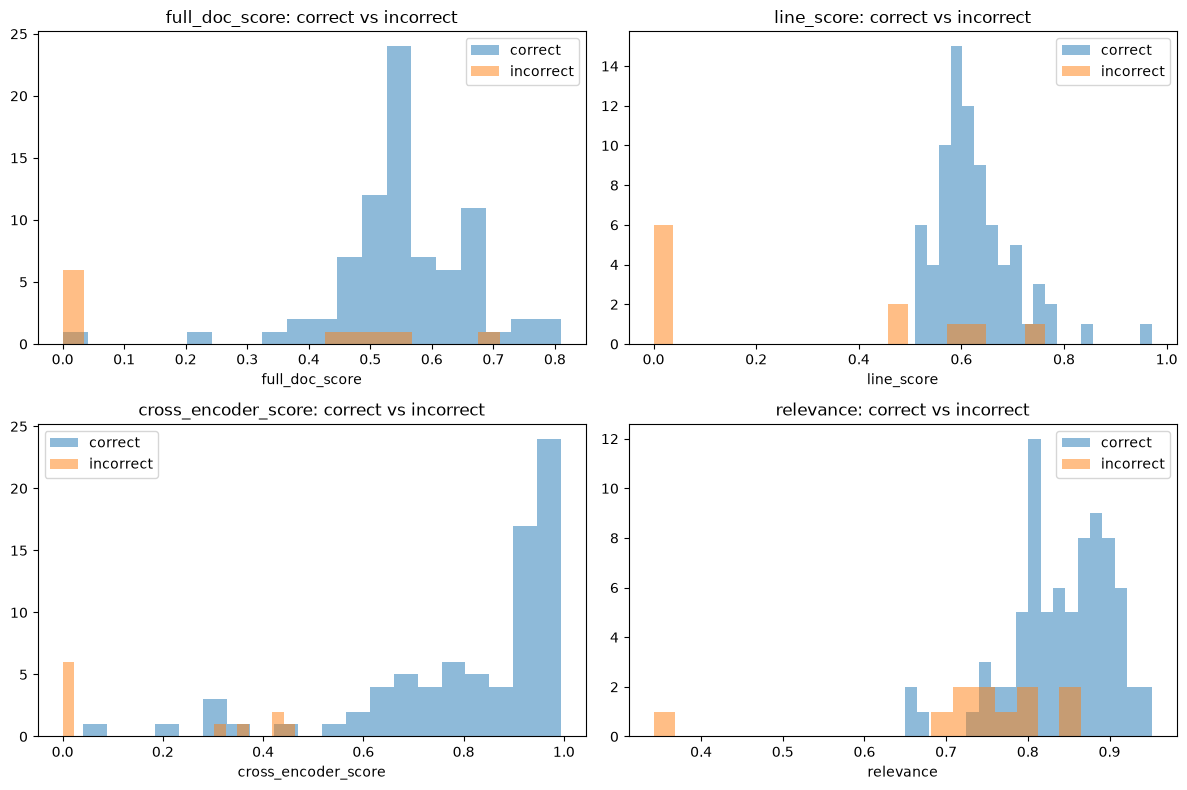

In [5]:
import matplotlib.pyplot as plt

%matplotlib inline
continuous = ["full_doc_score", "line_score", "cross_encoder_score", "relevance"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, m in zip(axes.ravel(), continuous):
    if gates[m].isna().all():
        ax.set_title(f"{m}: unavailable")
        continue
    ax.hist(gates.loc[gates["correct"], m], bins=20, alpha=0.5, label="correct")
    ax.hist(gates.loc[~gates["correct"], m], bins=20, alpha=0.5, label="incorrect")
    ax.set_title(f"{m}: correct vs incorrect")
    ax.set_xlabel(m)
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Threshold behavior

For each continuous measurement, find the smallest threshold t in 0.30..0.80
with FN rate <= 5% (correct accepted >= 95%) and report its FP rate and
acceptance rate — mirroring notebook 02 so the numbers are comparable. For the
binary `judged_grounded`, report FP/FN directly.

In [6]:
n_correct = int(gates["correct"].sum())
n_incorrect = int((~gates["correct"]).sum())
n_total = len(gates)


def threshold_behavior(meas):
    if meas == "judged_grounded":
        fp = int((~gates["correct"] & gates["judged_grounded"]).sum())
        fn = int((gates["correct"] & ~gates["judged_grounded"]).sum())
        acc = int(gates["judged_grounded"].sum())
        return {"measurement": meas, "threshold": "binary", "FN rate": fn / n_correct,
                "FP rate": fp / n_incorrect, "acceptance": acc / n_total}
    for t in np.arange(0.30, 0.81, 0.01):
        fn = int((gates["correct"] & (gates[meas] < t)).sum())
        if fn / n_correct <= 0.05:
            fp = int((~gates["correct"] & (gates[meas] >= t)).sum())
            acc = int((gates[meas] >= t).sum())
            return {"measurement": meas, "threshold": round(float(t), 2),
                    "FN rate": fn / n_correct, "FP rate": fp / n_incorrect,
                    "acceptance": acc / n_total}
    return {"measurement": meas, "threshold": None, "FN rate": None,
            "FP rate": None, "acceptance": None}


thresh_rows = [threshold_behavior(m) for m in measurements if not gates[m].isna().all()]
thresh = pd.DataFrame(thresh_rows).round(3)
thresh

,measurement,threshold,FN rate,FP rate,acceptance
0,full_doc_score,0.3,0.025,0.455,0.911
1,line_score,0.3,0.000,0.455,0.933
2,cross_encoder_score,0.3,0.038,0.455,0.900
3,relevance,0.3,0.000,1.000,1.000
4,judged_grounded,binary,0.000,0.182,0.900


## 6. Recommendation

Choose the production measurement weighing separation, FP/FN at the operating
point, and cost/latency (bi-encoder: local, fast; cross-encoder: local,
slower per-pair; LLM judge: one LLM call per answer).

**Why line_score >= 0.30 is recommended over the cross-encoder**

The acceptance criteria constrain **rejection <= 10%** and **correct accepted
>= 95%** (FN <= 5%) — they say nothing about FP.

- **line_score 0.30**: FN 0%, rejection 6.7% → criteria **MET**, at the
  cheapest cost (local ONNX, one encode per line, no LLM).
- **cross-encoder 0.30**: FN 3.8% → **FAILS** the correct-accepted >= 95% bar;
  to reach FP=0 you must accept FN=7.
- **LLM judge**: most accurate (FP 18.2%, FN 0%) but one LLM call per answer —
  keep for offline evaluation, not the runtime gate.

The recommendation is **criteria-driven, not accuracy-driven**. If the product
priority is "never show a wrong answer" (FP worse than FN), the cross-encoder
at t=0.5 (FP=0, FN=7) is the alternative.

In [7]:
line_rec = thresh[thresh["measurement"] == "line_score"].iloc[0]
cross_rec = thresh[thresh["measurement"] == "cross_encoder_score"].iloc[0]
judge_rec = thresh[thresh["measurement"] == "judged_grounded"].iloc[0]

print("RECOMMENDATION")
print(f"  production gate: line_score (line-level bi-encoder) at t={line_rec['threshold']}")
print(f"    FN rate={line_rec['FN rate']:.1%} | FP rate={line_rec['FP rate']:.1%} | acceptance={line_rec['acceptance']:.1%}")
print(f"    cost: local ONNX, fast (one encode per answer line) — no LLM call")
print()
print(f"  cross-encoder (AUROC {sep[sep['measurement']=='cross_encoder_score']['separation (AUROC)'].iloc[0]:.3f}):")
print(f"    best separation, but at the FN<=5% operating point (t={cross_rec['threshold']}) it does not beat")
print(f"    line_score on FP (FP rate={cross_rec['FP rate']:.1%}); at t=0.5 it reaches FP=0 at the cost of FN=7")
print(f"    cost: local but slower (one transformer pass per (answer, passage) pair)")
print()
print(f"  LLM judge (judged_grounded): FP rate={judge_rec['FP rate']:.1%}, FN rate={judge_rec['FN rate']:.1%}")
print(f"    most accurate, but one LLM call per answer — keep for offline evaluation, not the runtime gate")
print()
print("  => use line_score >= 0.30 in production (matches notebook 02);")
print("     revisit the cross-encoder if FP must be minimized (t=0.5, FP=0, FN=7);")
print("     keep the LLM judge as the offline accuracy ceiling.")

RECOMMENDATION
  production gate: line_score (line-level bi-encoder) at t=0.3
    FN rate=0.0% | FP rate=45.5% | acceptance=93.3%
    cost: local ONNX, fast (one encode per answer line) — no LLM call

  cross-encoder (AUROC 0.967):
    best separation, but at the FN<=5% operating point (t=0.3) it does not beat
    line_score on FP (FP rate=45.5%); at t=0.5 it reaches FP=0 at the cost of FN=7
    cost: local but slower (one transformer pass per (answer, passage) pair)

  LLM judge (judged_grounded): FP rate=18.2%, FN rate=0.0%
    most accurate, but one LLM call per answer — keep for offline evaluation, not the runtime gate

  => use line_score >= 0.30 in production (matches notebook 02);
     revisit the cross-encoder if FP must be minimized (t=0.5, FP=0, FN=7);
     keep the LLM judge as the offline accuracy ceiling.


## 7. Summary

- **line_score and full_doc_score separate correct from incorrect** (AUROC
  0.83 / 0.80); **relevance does not** (AUROC 0.82 but means 0.84 vs 0.73 with
  heavy overlap — the handoff hypothesis holds).
- **The cross-encoder separates best** (AUROC 0.97): incorrect answers score
  ~0.18 vs correct ~0.81, but at the FN<=5% operating point it matches
  line_score's FP rate; its 3 FN at t=0.30 are partly gate entries with no
  retrieved search texts.
- **The LLM judge is the accuracy ceiling** (FP=2, FN=0) but costs an LLM call
  per answer — appropriate for offline evaluation only.
- **Recommended production gate: line_score >= 0.30** (FN=0, FP=5/11,
  acceptance 93%) — cheap, local, and matches notebook 02's calibration.
- **For scoring.py**: implement the line-level grounding score (answer vs best
  matching line) as the gate measurement; **notebook 06** sweeps
  CONFIDENCE_THRESHOLD around 0.30 and can optionally test the cross-encoder
  at t=0.5 if FP must be minimized.